# **Deus Ex Machina - Project CS4**
## **(De)Generative AI**

### Group Members

- Catarina Monteiro
- Diogo Mendes
- Gonçalo Brochado
- Guilherme Vaz
- Matheus Bissacot

## **Brief Introduction**

The case study presented in the article "Generative AI Bias: A Growing Concern in the Industry" by Bloomberg examines the biases inherent in generative AI models, particularly focusing on Stable Diffusion. It highlights how these models often misrepresent racial and gender demographics in their outputs, perpetuating harmful stereotypes. In this notebook, we will present a step-by-step tutorial about how to avoid these serious issues using an example and applying various methodologies to handle imbalanced data.

## **Libraries**

The libraries that were used in these projects are:

- _pandas_ for manipulating datasets | **(Version 2.2.3)**
- _seaborn_ and _matplotlib_ for plot analysis | **(Version 0.13.2)**
- _sklearn_ for preprocessing data, applying algorithms and measuring test results | **(Version 1.5.2)**
- _xgboost_ for applying the XGBoost algorithm | **(Version 2.1.2)**
- _imblearn_ for applying the balance techniques | **(Version 0.12.4)**
- Python | **(version 3.11.7)**

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from imblearn.pipeline import Pipeline, make_pipeline
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, average_precision_score

## **Dataset Overview**

The [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download) dataset under review consists of credit card transactions made by European cardholders in September 2013, encompassing a total of 284,807 transactions, of which 492 are identified as fraudulent. 

This results in a highly unbalanced dataset, with fraud cases representing only 0.172% of all transactions. The dataset features numerical input variables derived from a Principal Component Analysis (PCA) transformation, with the original features not disclosed due to confidentiality concerns. The variables include 28 principal components (V1 to V28), along with two untransformed features: 'Time,' which indicates the seconds elapsed since the first transaction, and 'Amount,' representing the transaction value. 

The response variable, 'Class,' indicates fraud (1) or non-fraud (0). Given the significant class imbalance, it is recommended to evaluate model performance using the Area Under the Precision-Recall Curve (AUPRC) rather than traditional accuracy metrics, as confusion matrix accuracy may not provide meaningful insights in such scenarios. 

This dataset was collected and analyzed as part of a research collaboration between Worldline and the Machine Learning Group at ULB (Université Libre de Bruxelles) focused on big data mining and fraud detection.

In [2]:
df_credit = pd.read_csv("creditcard.csv")

The first steps are doing the basic analysis: how the dataset is composed, what are the relevant attributes and, in general, try to understand it better. Although simple, it is a crucial step, because after doing this, we understand what changes can be made to improve this dataset.

In [3]:
df_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df_credit['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

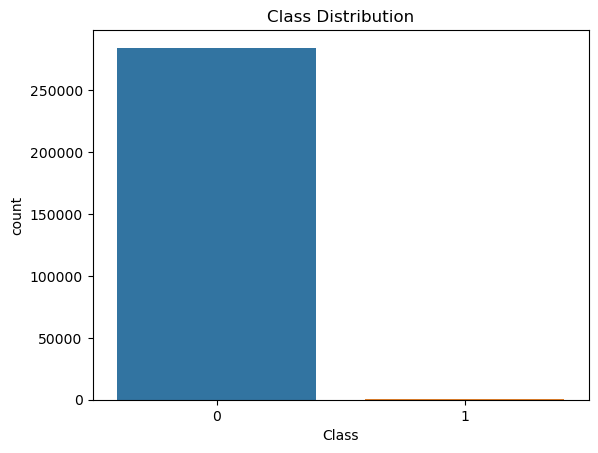

In [6]:
sns.countplot(x='Class', data=df_credit)
plt.title('Class Distribution')
plt.show()

Now let's see the **Time** and **Amount** attributes:

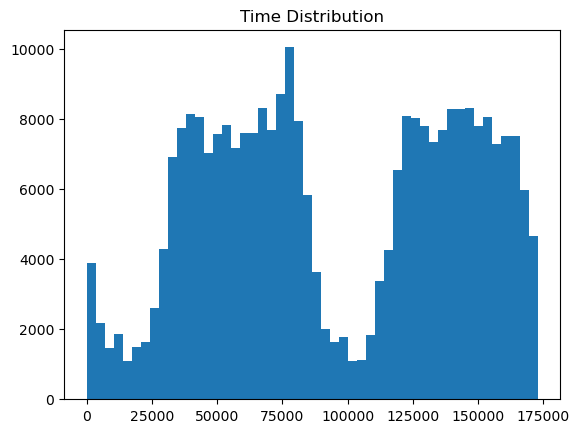

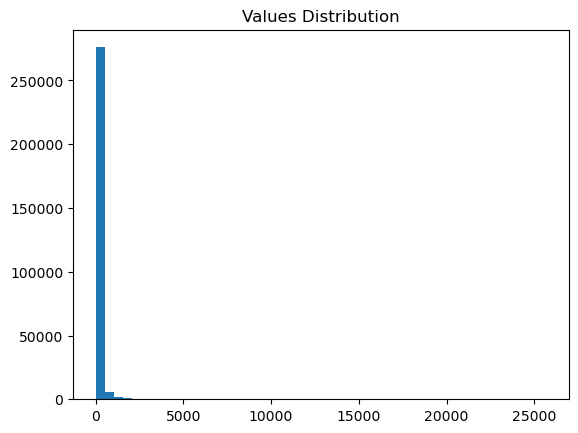

In [7]:
plt.hist(df_credit['Time'], bins=50)
plt.title('Time Distribution')
plt.show()

plt.hist(df_credit['Amount'], bins=50)
plt.title('Values Distribution')
plt.show()


In [11]:
X = df_credit.drop('Class', axis=1)
y = df_credit['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


## Random Forest

This is an Ensemble learning method that uses the bagging technique. Basically, it builds multiple decision trees from different subsets of the data, created using bootstrapping (sampling with replacement). Then, each tree makes a prediction, and the final output is determined by the majority voting, i.e the class most predicted by the trees. Finally, it randomly selects a subset of features at each split to reduce correlation between trees.

We chose these algorithm because it is robust to imbalanced data, have adjustable class weights, feature importance and easy-to-implement sampling strategies. Because of these aspects, this algorithm are widely used for researches similar to our case study and get very good results.

In [ ]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

Cross Validation Recall Scores are: [0.84057971 0.73913043 0.76811594 0.8115942  0.76470588]
Average Cross Validation Recall score: 0.7848252344416027


In [14]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [15]:
y_pred = model_rf.predict(X_test)

cm_standard_rf = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm_standard_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_standard_rf = pd.DataFrame(data)
print(df_standard_rf)

[[85291     4]
 [   36   112]]

          Model  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest   0.965517  0.756757  0.848485  0.999532  0.731083


## XGBoost

Also known as Extreme Gradient Boosting, this is a Gradient boosting framework. It sequentially builds decision trees, where each tree corrects the errors of the previous ones, and, at each step, minimizes a loss function (e.g., log loss for classification) by learning from the residuals. Then, regularization (L1/L2) is applied to control overfitting and, finally, combines the outputs of all trees to make predictions.

Although XGBoost doesn't get the same great results as Random Forest, they are still reliable enough to be picked. But the most important aspect for picking this algorithm definitely is to see how the changes and balance techniques can affect this.

In [ ]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))

Cross Validation Recall Scores are: [0.82608696 0.8115942  0.8115942  0.82608696 0.79411765]
Average Cross Validation Recall score: 0.8138959931798807


In [17]:
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [18]:
y_pred = model_xgb.predict(X_test)

cm_standard_xgb = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm_standard_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_standard_xgb = pd.DataFrame(data)
print(df_standard_xgb)

[[85279    16]
 [   31   117]]

     Model  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost   0.879699  0.790541   0.83274   0.99945  0.695801


## Balancing Techniques

Balancing techniques are methods used to address class imbalance in datasets, ensuring that the minority class is adequately represented during model training. These techniques include oversampling (e.g., SMOTE, ADASYN), undersampling (e.g., Tomek Links, Edited Nearest Neighbors), and hybrid approaches that combine both strategies. The goal of balancing is to improve the model's ability to learn patterns for the minority class, reducing bias and improving classification performance across all classes.

For each balanced dataset, two powerful machine learning algorithms, Random Forest (RF) and XGBoost, will be trained. This methodology ensures a thorough evaluation of how each balancing technique impacts the performance of RF and XGBoost, leveraging their strengths in ensemble learning and gradient boosting, respectively. The results will highlight the effectiveness of the balancing strategies and the predictive capabilities of the models under imbalanced conditions.

### Random Oversampling

Resampling refers to the process of generating a modified version of the training dataset where the examples exhibit a different class distribution. There are two primary methods for random resampling in the context of imbalanced classification: oversampling and undersampling.

These techniques are often called "naive resampling" methods because they do not make any assumptions about the data and do not utilize heuristics. This simplicity allows for easy implementation and quick execution, making them suitable for large and complex datasets.

Random Oversampling involves randomly duplicating instances from the minority class. Because it involves creating exact duplicates of the minority class examples, it can raise the risk of overfitting. For instance, if each data point from the minority class is replicated six times before the dataset is split, then during a 3-fold cross-validation, each fold would, on average, contain two copies of each minority class point. This situation can lead a classifier to develop rules that seem accurate but are actually based on just one of the replicated examples. As a result, the model may perform well on the training data but fail to generalize effectively to unseen data.

In [19]:
over = RandomOverSampler(random_state=42)

In [20]:
X_over, y_over = over.fit_resample(X_train, y_train)

In [21]:
print('0: ' + str(y_over.value_counts()[0]))
print('1: ' + str(y_over.value_counts()[1]))

0: 199020
1: 199020


In [22]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_over, y_over)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [23]:
y_pred = model_rf.predict(X_test)

cm_ro_rf = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm_ro_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Random Oversampling'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_ro_rf = pd.DataFrame(data)
print(df_ro_rf)

[[85290     5]
 [   40   108]]

          Model            Technique  Precision   Recall  F1 Score  Accuracy  \
0  RandomForest  Random Oversampling   0.955752  0.72973  0.827586  0.999473   

     AUPRCC  
0  0.697909  


In [24]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_over[y_over == 0]) / len(y_over[y_over == 1]))
model_xgb.fit(X_over, y_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [25]:
y_pred = model_xgb.predict(X_test)

cm_ro_xgb = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm_ro_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Random Oversampling'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_ro_xgb = pd.DataFrame(data)
print(df_ro_xgb)

[[85283    12]
 [   32   116]]

     Model            Technique  Precision    Recall  F1 Score  Accuracy  \
0  XGBoost  Random Oversampling    0.90625  0.783784   0.84058  0.999485   

     AUPRCC  
0  0.710679  


### Random Undersampling

Entails the random selection and removal of examples from the majority class in the training dataset. This method can be particularly effective for datasets with class imbalances, especially when there are enough examples in the minority class to build a reliable model. By reducing the number of majority class instances, random undersampling helps to balance the class distribution, which can enhance the model's ability to learn from the minority class without being overwhelmed by the majority class data.

In [26]:
under = RandomUnderSampler(random_state=42)

In [27]:
X_under, y_under = under.fit_resample(X_train, y_train)

In [28]:
print('0: ' + str(y_under.value_counts()[0]))
print('1: ' + str(y_under.value_counts()[1]))

0: 344
1: 344


In [29]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_under, y_under)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [30]:
y_pred = model_rf.predict(X_test)

cm_ru_rf = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm_ru_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Random Undersampling'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_ru_rf = pd.DataFrame(data)
print(df_ru_rf)

[[83696  1599]
 [   21   127]]

          Model             Technique  Precision    Recall  F1 Score  \
0  RandomForest  Random Undersampling   0.073581  0.858108  0.135539   

   Accuracy    AUPRCC  
0   0.98104  0.063386  


In [31]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_under[y_under == 0]) / len(y_under[y_under == 1]))
model_xgb.fit(X_under, y_under)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [32]:
y_pred = model_xgb.predict(X_test)

cm_ru_xgb = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm_ru_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Random Undersampling'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_ru_xgb = pd.DataFrame(data)
print(df_ru_xgb)

[[82239  3056]
 [   14   134]]

     Model             Technique  Precision    Recall  F1 Score  Accuracy  \
0  XGBoost  Random Undersampling   0.042006  0.905405  0.080288   0.96407   

     AUPRCC  
0  0.038197  


(Justificaçao do porque de neste caso isto nao ser uma abordagem viavel. Dataset de treino demasiado pequeno.)

### Class Weights

In [33]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42, class_weight="balanced")
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=50, n_jobs=-1,
                       random_state=42)

In [34]:
y_pred = model_rf.predict(X_test)

cm_cw_rf = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm_cw_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Class Weights'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_cw_rf = pd.DataFrame(data)
print(df_cw_rf)

[[85292     3]
 [   46   102]]

          Model      Technique  Precision    Recall  F1 Score  Accuracy  \
0  RandomForest  Class Weights   0.971429  0.689189  0.806324  0.999427   

     AUPRCC  
0  0.670036  


In [35]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
model_xgb = XGBClassifier(n_estimators=50, random_state=42, scale_pos_weight=scale_pos_weight)
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [36]:
y_pred = model_xgb.predict(X_test)

cm_cw_xgb = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm_cw_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Class Weights'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_cw_xgb = pd.DataFrame(data)
print(df_cw_xgb)

[[85270    25]
 [   31   117]]

     Model      Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost  Class Weights   0.823944  0.790541  0.806897  0.999345  0.651724


### SMOTE

The Synthetic Minority Oversampling Technique, in short, SMOTE,  method is used to address class imbalance by generating synthetic examples for the minority class. Instead of simply duplicating existing minority class instances, SMOTE creates new samples by selecting existing examples that are close to each other in the feature space.

The process involves the following steps:

1. Selection of Neighbors: For each instance in the minority class, SMOTE identifies its k-nearest neighbors (typically using Euclidean distance).

2. Interpolation: It then randomly selects one or more of these neighbors and creates new synthetic examples along the line segment that connects the original instance to the selected neighbor. This is done by interpolating between the feature values of the two instances.

3. New Sample Generation: The new sample is generated at a point along this line, which introduces variability and helps to create a more diverse set of examples for the minority class.

By synthesizing new instances rather than merely replicating existing ones, SMOTE helps to improve the model's ability to generalize and reduces the risk of overfitting that can occur with simple oversampling techniques.

In [37]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Distribution after SMOTE: {pd.Series(y_train_smote).value_counts()}")

Distribution after SMOTE: Class
0    199020
1    199020
Name: count, dtype: int64


In [38]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [39]:
y_pred = model_rf.predict(X_test)

cm_smote_rf = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm_smote_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_smote_rf = pd.DataFrame(data)
print(df_smote_rf)

[[85277    18]
 [   33   115]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest     SMOTE   0.864662  0.777027  0.818505  0.999403  0.672252


In [40]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smote[y_train_smote == 0]) / len(y_train_smote[y_train_smote == 1]))
model_xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [41]:
y_pred = model_xgb.predict(X_test)

cm_smote_xgb = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm_smote_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['SMOTE'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_smote_xgb = pd.DataFrame(data)
print(df_smote_xgb)

[[85257    38]
 [   29   119]]

     Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost     SMOTE   0.757962  0.804054  0.780328  0.999216  0.609782


### B-SMOTE

An enhancement of the original SMOTE, Borderline SMOTE focuses on generating synthetic samples for the minority class near decision boundaries. First it identifies "borderline" samples from the minority class: these are instances close to the majority class or within dense overlapping regions. Then, it generates synthetic samples only for these borderline instances, as they are most at risk of being misclassified.

In [42]:
bsmote = BorderlineSMOTE(random_state=42)
X_train_bsmote, y_train_bsmote = bsmote.fit_resample(X_train, y_train)

print(f"Distribution after B-SMOTE: {pd.Series(y_train_smote).value_counts()}")

Distribution after B-SMOTE: Class
0    199020
1    199020
Name: count, dtype: int64


In [43]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_bsmote, y_train_bsmote)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [44]:
y_pred = model_rf.predict(X_test)

cm_bsmote_rf = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm_bsmote_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['B-SMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_bsmote_rf = pd.DataFrame(data)
print(df_bsmote_rf)

[[85290     5]
 [   37   111]]

          Model Technique  Precision  Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest   B-SMOTE   0.956897    0.75  0.840909  0.999508  0.718105


In [45]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_bsmote[y_train_bsmote == 0]) / len(y_train_bsmote[y_train_bsmote == 1]))
model_xgb.fit(X_train_bsmote, y_train_bsmote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [46]:
y_pred = model_xgb.predict(X_test)

cm_bsmote_xgb = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm_bsmote_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['B-SMOTE'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_bsmote_xgb = pd.DataFrame(data)
print(df_bsmote_xgb)

[[85274    21]
 [   31   117]]

     Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost   B-SMOTE   0.847826  0.790541  0.818182  0.999391  0.670604


### ADASYN

This is a variant of SMOTE that generates synthetic samples adaptively based on the difficulty of classifying minority class instances. It measures the difficulty of classifying each minority class instance using a metric (e.g., the number of majority class neighbors within a radius), assigns higher weights to more difficult instances and generates more synthetic samples for these areas and creates a balanced dataset while prioritizing regions where the model struggles the most.

In [47]:
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

In [48]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_adasyn, y_train_adasyn)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [49]:
y_pred = model_rf.predict(X_test)

cm_adasyn_rf = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm_adasyn_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['ADASYN'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_adasyn_rf = pd.DataFrame(data)
print(df_adasyn_rf)

[[85279    16]
 [   36   112]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest    ADASYN      0.875  0.756757  0.811594  0.999391  0.662583


In [50]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_adasyn[y_train_adasyn == 0]) / len(y_train_adasyn[y_train_adasyn == 1]))
model_xgb.fit(X_train_adasyn, y_train_adasyn)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [51]:
y_pred = model_xgb.predict(X_test)

cm_adasyn_xgb = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm_adasyn_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['ADASYN'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_adasyn_xgb = pd.DataFrame(data)
print(df_adasyn_xgb)

[[85240    55]
 [   33   115]]

     Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost    ADASYN   0.676471  0.777027   0.72327   0.99897  0.526022


### SMOTE-Tomek

Tomek Links is an under-sampling technique developed in 1976 by Ivan Tomek. It is a modification of the Condensed Nearest Neighbors (CNN) algorithm. Tomek Links can be used to identify and remove samples from the majority class that have the lowest Euclidean distance to the minority class data.

Combining over-sampling of the minority (abnormal) class with under-sampling of the majority (normal) class can achieve better classifier performance than only under-sampling the majority class.

First, it begins the SMOTE process by choosing random data from the minority class. Then, it calculates the distance between the random data and its k nearest neighbors. After that, multiply the difference with a random number between 
0 and 1, then add the result to the minority class as a synthetic sample and then repeat the two last steps until the desired proportion of the minority class is met, reaching the end of the SMOTE.

The start of Tomek Links choose random data from the minority class and, if the random data’s nearest neighbor is data from the minority class, then remove the Tomek Link.

By following these steps, the SMOTE-Tomek Links method helps to balance the dataset by both generating synthetic minority class samples and removing majority class samples that are close to the minority class, thus improving the classifier's performance.

This is a hybrid method combining SMOTE for oversampling and Tomek Links for undersampling, aiming to balance the dataset while improving class separation. 

In [52]:
SMOTETomek_pipeline = make_pipeline(SMOTETomek(tomek=TomekLinks(sampling_strategy='majority')), 
                              RandomForestClassifier(n_estimators=50, random_state=42))

In [53]:
SMOTETomek_rf = SMOTETomek_pipeline
SMOTETomek_rf.fit(X_train, y_train)

Pipeline(steps=[('smotetomek',
                 SMOTETomek(tomek=TomekLinks(sampling_strategy='majority'))),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=50, random_state=42))])

In [54]:
smote_tomek = SMOTETomek(random_state=42)
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train)

In [55]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_smote_tomek, y_train_smote_tomek)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [56]:
y_pred = model_rf.predict(X_test)

cm_smotetomek_rf = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm_smotetomek_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTE-Tomek'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_smotetomek_rf = pd.DataFrame(data)
print(df_smotetomek_rf)

[[85277    18]
 [   33   115]]

          Model    Technique  Precision    Recall  F1 Score  Accuracy  \
0  RandomForest  SMOTE-Tomek   0.864662  0.777027  0.818505  0.999403   

     AUPRCC  
0  0.672252  


In [57]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smote_tomek[y_train_smote_tomek == 0]) / len(y_train_smote_tomek[y_train_smote_tomek == 1]))
model_xgb.fit(X_train_smote_tomek, y_train_smote_tomek)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [58]:
y_pred = model_xgb.predict(X_test)

cm_smotetomek_xgb = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm_smotetomek_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['SMOTE-Tomek'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_smotetomek_xgb = pd.DataFrame(data)
print(df_smotetomek_xgb)

[[85257    38]
 [   29   119]]

     Model    Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost  SMOTE-Tomek   0.757962  0.804054  0.780328  0.999216  0.609782


### SMOTEENN

The SMOTE + Edited Nearest Neighbors is a hybrid technique that combines SMOTE (oversampling) with Edited Nearest Neighbors (ENN, undersampling) to address class imbalance by balancing the dataset and removing noisy samples.

This works by generating synthetic samples for the minority class to reduce imbalance (the SMOTE part) and cleaning the dataset by removing samples whose class label differs from the majority of its nearest neighbors, typically 3-nearest neighbors. This step removes noisy and ambiguous samples from both classes, especially at the decision boundary.

In [59]:
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train, y_train)

In [60]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_smoteenn, y_train_smoteenn)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [61]:
y_pred = model_rf.predict(X_test)

cm_smotenn_rf = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm_smotenn_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTEENN'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_smotenn_rf = pd.DataFrame(data)
print(df_smotenn_rf)

[[85262    33]
 [   31   117]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest  SMOTEENN       0.78  0.790541  0.785235  0.999251  0.616984


In [62]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smoteenn[y_train_smoteenn == 0]) / len(y_train_smoteenn[y_train_smoteenn == 1]))
model_xgb.fit(X_train_smoteenn, y_train_smoteenn)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [63]:
y_pred = model_xgb.predict(X_test)

cm_smotenn_xgb = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm_smotenn_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['SMOTEENN'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_smotenn_xgb = pd.DataFrame(data)
print(df_smotenn_xgb)

[[85228    67]
 [   27   121]]

     Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost  SMOTEENN   0.643617  0.817568  0.720238    0.9989  0.526516


### Hybrid Tomek Links BCBSMOTE (Proposed in Paper)

This approach combines the strengths of Borderline-SMOTE (BC-SMOTE) and Tomek Links to balance datasets and refine decision boundaries. BC-SMOTE focuses on generating synthetic samples for the minority class, specifically for borderline instances near the decision boundary, thereby improving minority class representation in the most challenging regions. Tomek Links identifies and removes pairs of nearest neighbors (one from each class) that are too close, typically considered noise or borderline majority class samples. This process cleans the dataset by improving class separability and removing ambiguity.

In [64]:
# Step 1: Clustering and border identification
minority_class = X_train[y_train == 1]
kmeans = KMeans(n_clusters=5, random_state=42).fit(minority_class)

/home/codebind/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [65]:
# Passo 2: BCBSMOTE - Generation of synthetic samples
synthetic_samples = []

for cluster in range(5):
    cluster_data = minority_class[kmeans.labels_ == cluster]
    cluster_data = cluster_data.to_numpy()  # Converts to NumPy to avoid index problems

    nbrs = NearestNeighbors(n_neighbors=3).fit(cluster_data)
    distances, indices = nbrs.kneighbors(cluster_data)

    for i, neighbors in enumerate(indices):
        for neighbor in neighbors:
            if neighbor != i:  # Avoid interpolation in the same spot
                synthetic_sample = cluster_data[i] + np.random.rand() * (cluster_data[neighbor] - cluster_data[i])
                synthetic_samples.append(synthetic_sample)

synthetic_samples = np.array(synthetic_samples)
X_resampled = np.vstack([X_train, synthetic_samples])
y_resampled = np.hstack([y_train, np.ones(synthetic_samples.shape[0])])

In [66]:
# Step 3: Tomek Links
smote_tomek = SMOTETomek(random_state=42)
X_train_smote_tomek2, y_train_smote_tomek2 = smote_tomek.fit_resample(X_resampled, y_resampled)

In [67]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_smote_tomek2, y_train_smote_tomek2)

RandomForestClassifier(random_state=42)

In [68]:
y_pred = model_rf.predict(X_test)

cm_bcbsmote_rf = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm_bcbsmote_rf)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Hybrid Tomek Links BCBSMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df_bcbsmote_rf = pd.DataFrame(data)
print(df_bcbsmote_rf)

[[85262    33]
 [   31   117]]

          Model                    Technique  Precision    Recall  F1 Score  \
0  RandomForest  Hybrid Tomek Links BCBSMOTE       0.78  0.790541  0.785235   

   Accuracy    AUPRCC  
0  0.999251  0.616984  


In [69]:
# Passo 4: Treinar o modelo
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smote_tomek2[y_train_smote_tomek2 == 0]) / len(y_train_smote_tomek2[y_train_smote_tomek2 == 1]))
model_xgb.fit(X_train_smote_tomek2, y_train_smote_tomek2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [70]:
y_pred = model_xgb.predict(X_test)

cm_bcbsmote_xgb = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm_bcbsmote_xgb)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Hybrid Tomek Links BCBSMOTE'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df_bcbsmote_xgb = pd.DataFrame(data)
print(df_bcbsmote_xgb)

[[85278    17]
 [   30   118]]

     Model                    Technique  Precision    Recall  F1 Score  \
0  XGBoost  Hybrid Tomek Links BCBSMOTE   0.874074  0.797297  0.833922   

   Accuracy    AUPRCC  
0   0.99945  0.697248  


## Results

After analyzing all the possible approaches for balancing our dataset, we can make a fair comparison on how the algorithms perform before and after the Balancing Techniques. What we expect is a improvement on aspects such as Recall, F1 Score and the Area Under the Precision-Recall Curve. We already had these values when discussing the approaches. All we have to do is merge them and then, graphically, we can analyze if the results correspond with our expectations.

In [ ]:
# List of DataFrames
dfs_rf = [df_standard_rf, df_ro_rf, df_cw_rf, df_smote_rf, df_bsmote_rf, df_adasyn_rf, df_smotetomek_rf, df_smotenn_rf, df_bcbsmote_rf]
dfs_xgb = [df_standard_xgb, df_ro_xgb, df_cw_xgb, df_smote_xgb, df_bsmote_xgb, df_adasyn_xgb, df_smotetomek_xgb, df_smotenn_xgb, df_bcbsmote_xgb]

# Concatenate into a single DataFrame
combined_df_rf = pd.concat(dfs_rf, ignore_index=True)
combined_df_xgb = pd.concat(dfs_xgb, ignore_index=True)

combined_df_rf['Technique'] = combined_df_rf['Technique'].fillna('Standard Random Forest')
combined_df_xgb['Technique'] = combined_df_rf['Technique'].fillna('Standard XGBoost')

# Preview the combined DataFrame
print(combined_df_rf)
print(combined_df_xgb)


          Model  Precision    Recall  F1 Score  Accuracy    AUPRCC  \
0  RandomForest   0.965517  0.756757  0.848485  0.999532  0.731083   
1  RandomForest   0.955752  0.729730  0.827586  0.999473  0.697909   
2  RandomForest   0.971429  0.689189  0.806324  0.999427  0.670036   
3  RandomForest   0.864662  0.777027  0.818505  0.999403  0.672252   
4  RandomForest   0.956897  0.750000  0.840909  0.999508  0.718105   
5  RandomForest   0.875000  0.756757  0.811594  0.999391  0.662583   
6  RandomForest   0.864662  0.777027  0.818505  0.999403  0.672252   
7  RandomForest   0.780000  0.790541  0.785235  0.999251  0.616984   
8  RandomForest   0.780000  0.790541  0.785235  0.999251  0.616984   

                     Technique  
0       Standard Random Forest  
1          Random Oversampling  
2                Class Weights  
3                        SMOTE  
4                      B-SMOTE  
5                       ADASYN  
6                  SMOTE-Tomek  
7                     SMOTEENN  
8 

### Random Forest Analysis

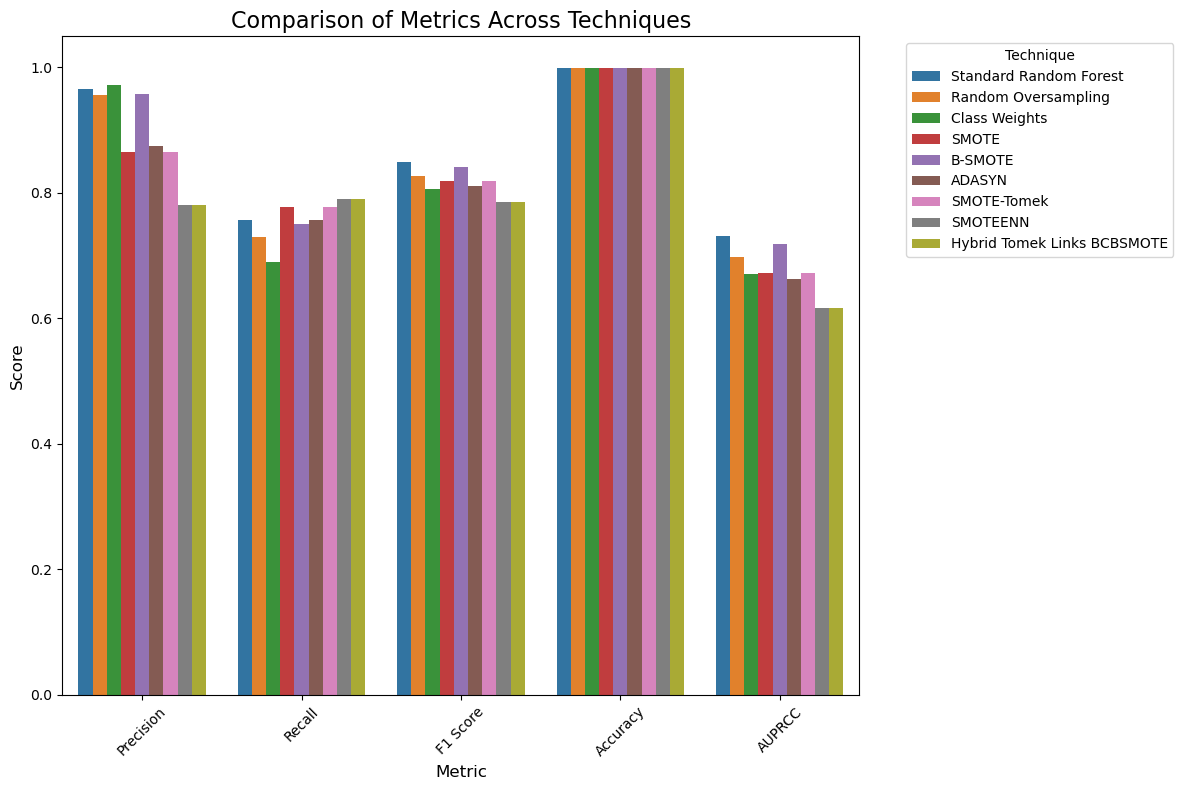

In [93]:
# Set the figure size
plt.figure(figsize=(12, 8))

# Melt the DataFrame for better visualization
melted_df = combined_df_rf.melt(id_vars=['Model', 'Technique'], 
                              value_vars=['Precision', 'Recall', 'F1 Score', 'Accuracy', 'AUPRCC'],
                              var_name='Metric', value_name='Value')

# Create the grouped bar plot
sns.barplot(data=melted_df, x='Metric', y='Value', hue='Technique')

# Customize the plot
plt.title('Comparison of Metrics Across Techniques', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Technique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

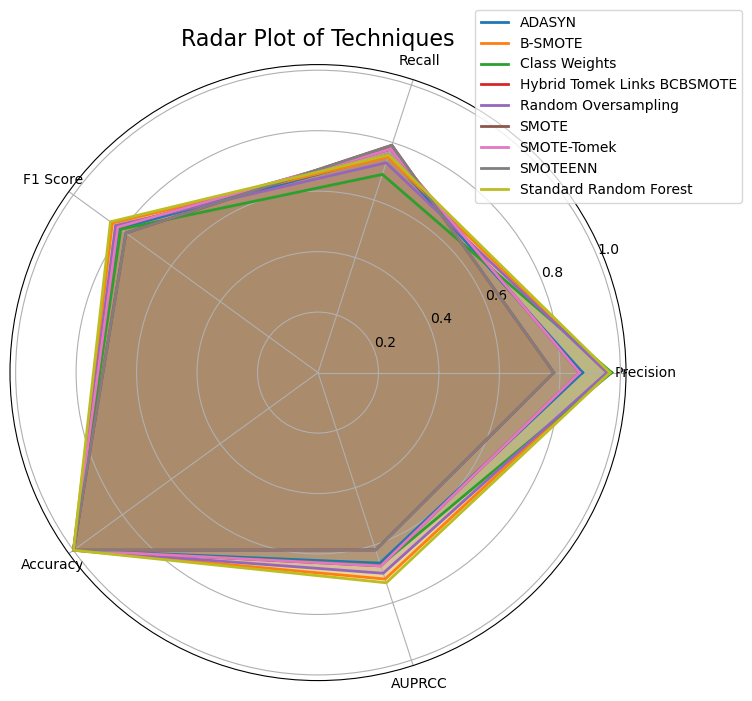

In [94]:
from math import pi

# Average values for each technique (group by Technique)
radar_data = combined_df_rf.groupby('Technique')[['Precision', 'Recall', 'F1 Score', 'Accuracy', 'AUPRCC']].mean()

# Add a row to close the radar plot
radar_data.loc['close'] = radar_data.iloc[0]

# Radar plot setup
labels = radar_data.columns
num_vars = len(labels)

# Calculate angles
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]  # Close the radar plot

# Create the radar plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each technique
for technique in radar_data.index[:-1]:  # Exclude the closing row
    values = radar_data.loc[technique].tolist()
    values += values[:1]  # Close the chart
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=technique)
    ax.fill(angles, values, alpha=0.25)

# Add labels and legend
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title('Radar Plot of Techniques', fontsize=16)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()


The "Standard Random Forest" (without any balancing) performs well, but some balancing techniques, such as "B-SMOTE" and "Random Oversampling," improve Precision slightly. However, techniques like SMOTE and SMOTEENN have marginally lower Precision, indicating they might be introducing some noise. Balancing techniques generally improve Recall compared to the "Standard Random Forest," with methods like SMOTE, B-SMOTE, and ADASYN showing significant improvement, indicating better handling of the minority class.

In terms of the F1 Score, balancing techniques like B-SMOTE and Random Oversampling improve the score, suggesting they effectively balance Precision and Recall. Conversely, some techniques, such as SMOTEENN, perform worse than others, indicating trade-offs between Precision and Recall. Accuracy remains consistently high across all methods, including the "Standard Random Forest," which is expected in imbalanced datasets where the majority class dominates. However, accuracy alone is not a good indicator of performance for imbalanced datasets.

Regarding AUPRCC (Area Under the Precision-Recall Curve), the "Standard Random Forest" has the highest AUPRCC, but B-SMOTE, ADASYN, and SMOTE-Tomek are close. AUPRCC emphasizes performance on the minority class, and slight drops in this metric suggest trade-offs with balancing methods.

### XGBoost Analysis

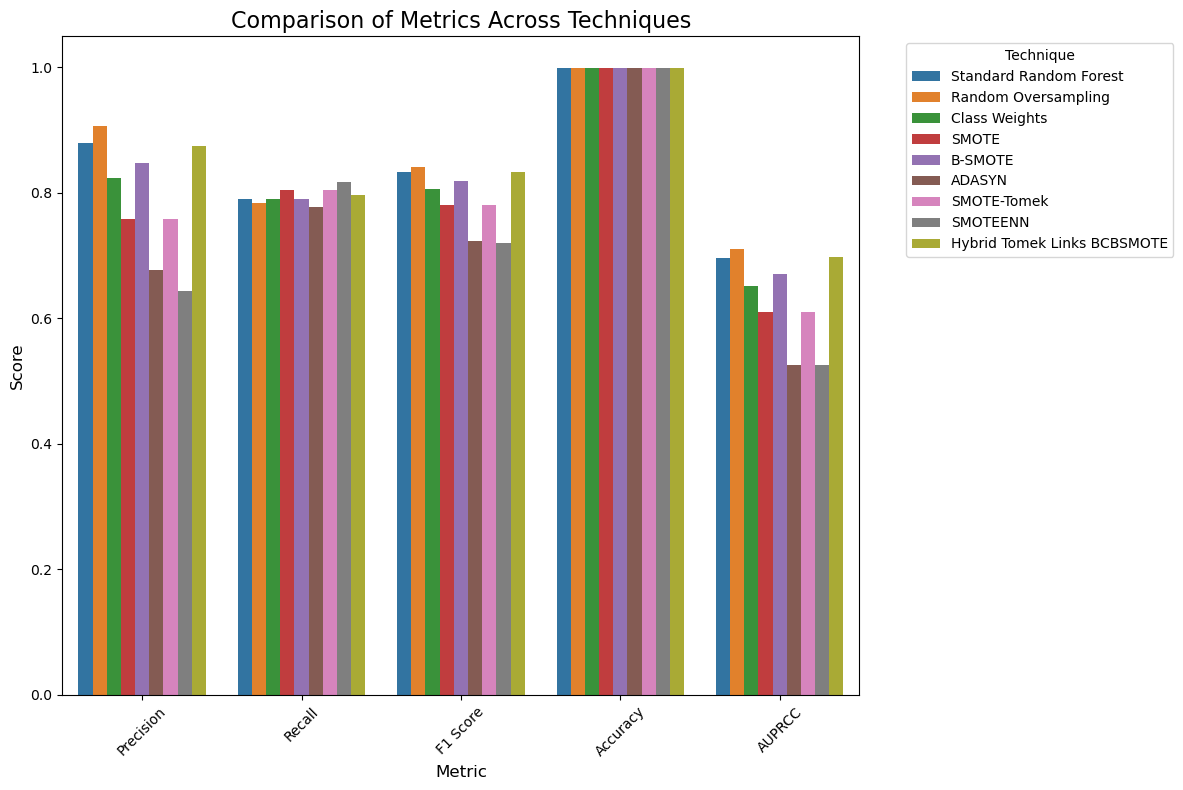

In [95]:
# Set the figure size
plt.figure(figsize=(12, 8))

# Melt the DataFrame for better visualization
melted_df = combined_df_xgb.melt(id_vars=['Model', 'Technique'], 
                              value_vars=['Precision', 'Recall', 'F1 Score', 'Accuracy', 'AUPRCC'],
                              var_name='Metric', value_name='Value')

# Create the grouped bar plot
sns.barplot(data=melted_df, x='Metric', y='Value', hue='Technique')

# Customize the plot
plt.title('Comparison of Metrics Across Techniques', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Technique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

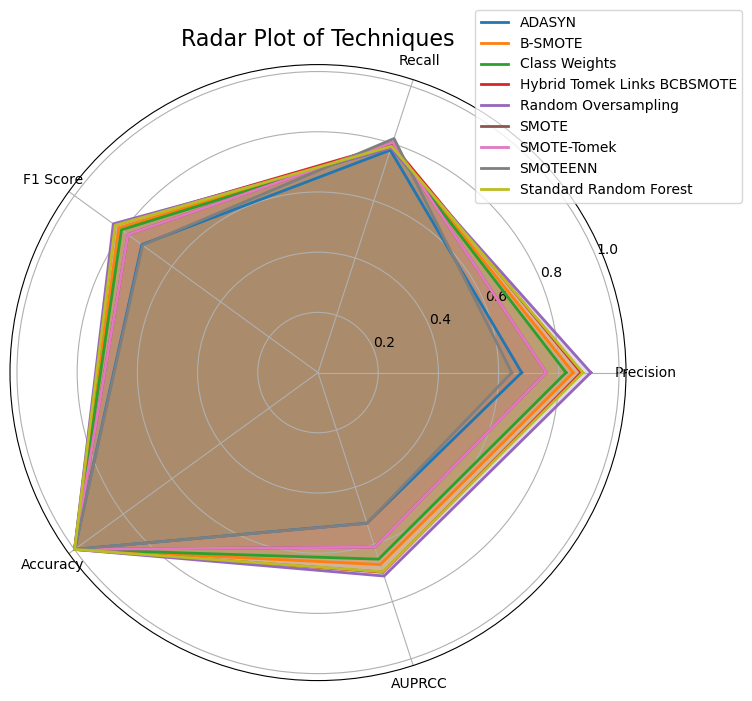

In [96]:
from math import pi

# Average values for each technique (group by Technique)
radar_data = combined_df_xgb.groupby('Technique')[['Precision', 'Recall', 'F1 Score', 'Accuracy', 'AUPRCC']].mean()

# Add a row to close the radar plot
radar_data.loc['close'] = radar_data.iloc[0]

# Radar plot setup
labels = radar_data.columns
num_vars = len(labels)

# Calculate angles
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]  # Close the radar plot

# Create the radar plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each technique
for technique in radar_data.index[:-1]:  # Exclude the closing row
    values = radar_data.loc[technique].tolist()
    values += values[:1]  # Close the chart
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=technique)
    ax.fill(angles, values, alpha=0.25)

# Add labels and legend
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title('Radar Plot of Techniques', fontsize=16)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

XGBoost exhibits consistently high Precision across techniques, with methods like Random Oversampling and B-SMOTE marginally enhancing Precision compared to the Standard Random Forest baseline. In terms of Recall, XGBoost benefits significantly from balancing techniques, with methods such as SMOTE, SMOTEENN, and B-SMOTE yielding noticeable gains. These techniques are particularly valuable for imbalanced datasets, and additional balancing techniques like Hybrid Tomek Links BCBSMOTE seem to maintain a competitive edge.

The F1 Score reflects the trade-off between Precision and Recall, and techniques such as ADASYN, SMOTE, and B-SMOTE perform well in achieving a balance, with SMOTEENN also showing promising results. The Accuracy metric remains consistently very high, showing minimal variation across techniques. This suggests that for XGBoost, Accuracy alone may not fully reflect the effectiveness of balancing techniques, as it tends to remain robust even without heavy class balancing.

Regarding AUPRCC (Area Under Precision-Recall Curve), this metric provides insight into model performance for imbalanced datasets. Techniques like B-SMOTE, SMOTE, and Random Oversampling clearly boost AUPRCC, while SMOTEENN lags slightly. This indicates that these techniques better handle the minority class for XGBoost.

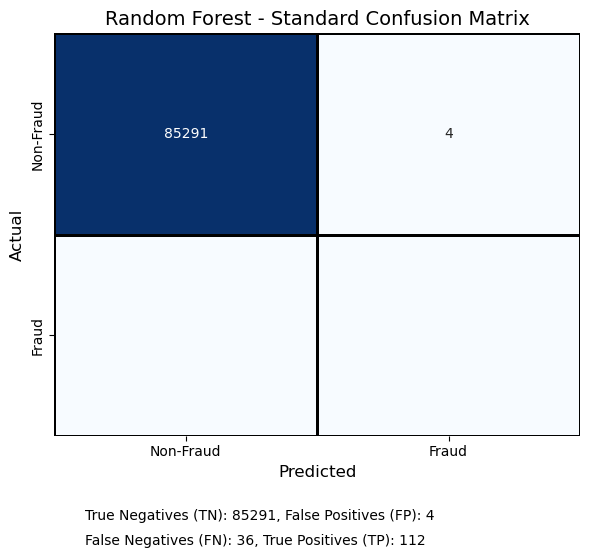

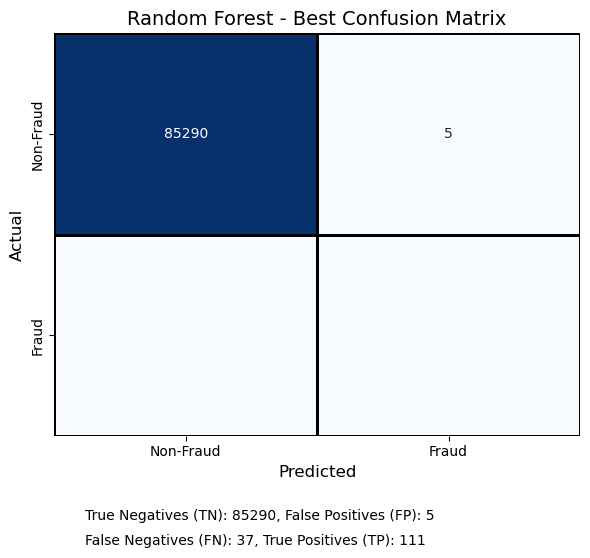

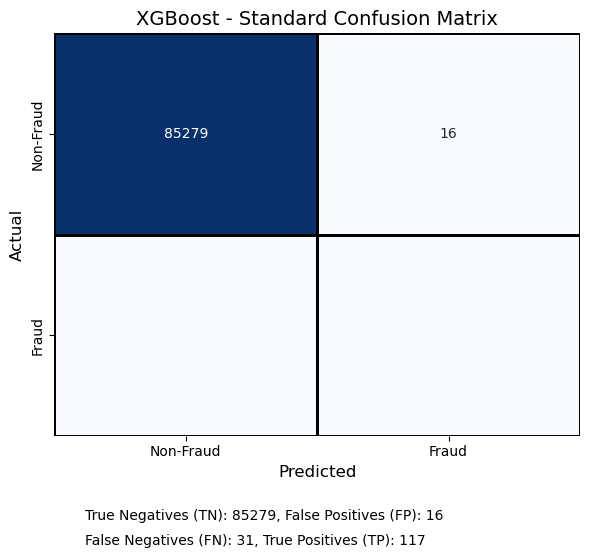

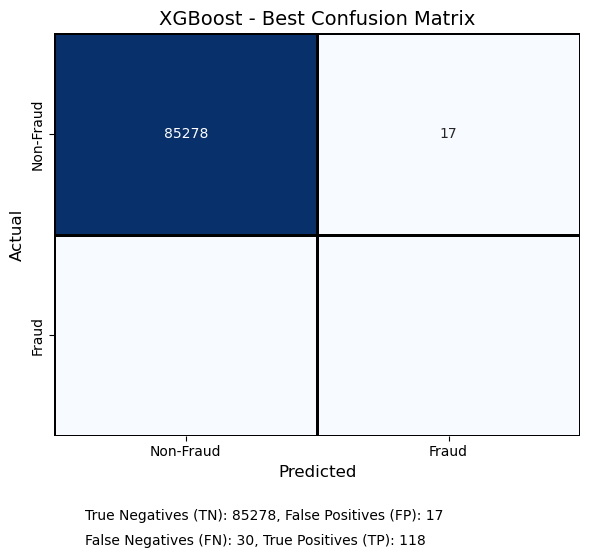

In [ ]:
# Improved plotting function
def plot_confusion_matrix(cm, title='Confusion Matrix', labels=['Non-Fraud', 'Fraud']):
    """
    Plots a confusion matrix with all values (including the two bottom values for fraud cases).
    """
    # Manually calculate total TN, FP, FN, TP for clear labeling
    TN, FP, FN, TP = np.array(cm).ravel()

    # Display matrix with annotations
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False, linewidths=1, linecolor='black')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    plt.title(title, fontsize=14)

    # Add bottom text for Fraud and Non-Fraud
    plt.figtext(0.15, -0.05, f"True Negatives (TN): {TN}, False Positives (FP): {FP}", fontsize=10, ha="left")
    plt.figtext(0.15, -0.10, f"False Negatives (FN): {FN}, True Positives (TP): {TP}", fontsize=10, ha="left")

    plt.tight_layout()
    plt.show()

In [ ]:
plot_confusion_matrix(cm_standard_rf, title='Random Forest - Standard Confusion Matrix')
plot_confusion_matrix(cm_bsmote_rf, title='Random Forest - Best Confusion Matrix')


In [ ]:
plot_confusion_matrix(cm_standard_xgb, title='XGBoost - Standard Confusion Matrix')
plot_confusion_matrix(cm_bcbsmote_xgb, title='XGBoost - Best Confusion Matrix')

### Key Takeaways

Balancing techniques, such as SMOTE, B-SMOTE, and Random Oversampling, are consistently effective in improving model performance across algorithms like Random Forest and XGBoost, particularly in addressing imbalanced datasets. These methods enhance critical metrics like Recall and F1 Score, showcasing their ability to reduce false negatives while maintaining competitive Precision. However, there is an inherent trade-off between Precision and Recall, as balancing often leads to slight decreases in Precision. This trade-off is significant depending on whether false positives or false negatives are prioritized.

SMOTEENN, while effective in boosting Recall and Precision in some cases, tends to underperform in metrics like AUPRCC, possibly due to over-cleaning or introducing noise during balancing. The performance of balancing techniques like B-SMOTE and Random Oversampling demonstrates their versatility and reliability across both algorithms, with Random Forest and XGBoost benefiting from these methods. Moreover, the high accuracy observed for all techniques highlights its inadequacy as the sole metric for evaluating imbalanced datasets. Metrics such as F1 Score, Recall, and AUPRCC provide a more nuanced understanding of model performance and should be prioritized in such scenarios.

## Conclusion

This case study explores the challenge of handling imbalanced datasets, using the [Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download) as a representative example, and examines the impact of various balancing techniques on the performance of machine learning algorithms. By employing Random Forest and XGBoost as the primary models, the study evaluates the effectiveness of these techniques in improving classification performance across key metrics such as Precision, Recall, F1 Score, Accuracy, and AUPRCC.

**Key Findings:**

1. **Imbalance Challenges and Metric Selection**:  
   The severe class imbalance in the dataset (fraudulent transactions making up only 0.17% of the total) emphasizes the inadequacy of accuracy as a sole evaluation metric. Despite both algorithms achieving high accuracy across all experiments, metrics like Recall, F1 Score, and AUPRCC proved more insightful in assessing performance, particularly for the minority class. This reinforces the importance of using metrics tailored to the needs of imbalanced datasets.

2. **Baseline Performance**:  
   Without balancing techniques, both Random Forest and XGBoost exhibited strong Precision but struggled with Recall, leading to suboptimal F1 Scores. This highlights a common issue in imbalanced datasets, where models prioritize the majority class, often at the expense of identifying minority class instances (fraudulent transactions in this case).

3. **Impact of Balancing Techniques**:  
   Incorporating balancing techniques such as Random Oversampling, SMOTE, B-SMOTE, ADASYN, SMOTE-Tomek, SMOTEENN, and Hybrid Tomek Links BCBSMOTE substantially improved Recall and F1 Score for both algorithms, addressing the minority class bias. However, there was a trade-off with Precision, as balancing techniques occasionally introduced false positives by over-representing the minority class.  
   - **Random Oversampling** and **B-SMOTE** consistently delivered a good balance across all metrics, making them reliable choices for both Random Forest and XGBoost.  
   - **SMOTEENN**, while improving Recall, struggled with AUPRCC, likely due to over-cleaning or noise introduced during the resampling process, particularly in extreme imbalance scenarios.

4. **Algorithm-Specific Observations**:  
   - **Random Forest** showed robust performance gains from balancing techniques, particularly benefiting from methods like Random Oversampling, SMOTE, and ADASYN. The improvements were most notable in Recall and F1 Score, making it a strong contender for fraud detection in imbalanced datasets.  
   - **XGBoost**, a gradient boosting method, demonstrated consistent performance across all balancing techniques, with strong improvements in Recall, Precision, and F1 Score. This highlights its ability to adapt to resampled datasets effectively. Notably, SMOTEENN's underperformance in AUPRCC was more apparent with XGBoost.

5. **Trade-offs and Practical Implications**:  
   The trade-off between Precision and Recall underscores the importance of aligning model evaluation with the specific needs of the application. For example, in fraud detection, prioritizing Recall to minimize false negatives (missed fraud cases) may be more critical, even at the cost of slightly reduced Precision. Balancing techniques like B-SMOTE and Random Oversampling offer a promising compromise, improving overall detection rates without excessively inflating false positives.

**Conclusion**:  
Balancing techniques significantly enhance the effectiveness of machine learning models in tackling imbalanced datasets, as evidenced by the improvements in Recall, F1 Score, and AUPRCC for both Random Forest and XGBoost. These results reaffirm the importance of carefully selecting and tuning resampling methods based on the dataset and the business context. While balancing techniques address the bias toward the majority class, they introduce trade-offs that must be managed to ensure optimal model performance.

This study underscores the need for a metric-driven approach to evaluate models on imbalanced datasets and demonstrates that combining robust algorithms like Random Forest and XGBoost with effective balancing techniques can yield powerful solutions for fraud detection and other imbalanced classification tasks.

## Bibliography:

**https://www.researchgate.net/publication/377619332_Hybrid_Undersampling_and_Oversampling_for_Handling_Imbalanced_Credit_Card_Data**

(Adicionar mais referências)

dataprep para data profiling

problexity para fazer plot com medidas de complexidade
perceber com base nas medidas do dataset se faz sentido (a nossa melhor) ser o melhor 
perceber se operaçao de limpeza ajudou (após limpeza , antes do smote)

isa para original e isa para smote